In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import pickle
import joblib
import os
#Load estimation dataset
data_path1 = Path.home() / "Prepayment_Analysis_Data" / "mort_for_estimation.csv"
mort_est_df = pd.read_csv(data_path1, header=0, parse_dates=['ORIG_DATE1', 'DATE_NOW'])
data_path2 = Path.home() / "Prepayment_Analysis_Data" / "mort_for_prediction.csv"
mort_pred_df = pd.read_csv(data_path2, header=0, parse_dates=['ORIG_DATE1', 'DATE_NOW'])

In [2]:
#Estimate logit model
X = mort_est_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
y = mort_est_df['PREPAY_FLAG']
X = sm.add_constant(X)
cloglog_model = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.CLogLog()))
result = cloglog_model.fit(cov_type='cluster', cov_kwds={'groups': mort_est_df['LOAN_ID']})
print(result.summary())
y_prob = result.predict(X)
result.remove_data()
folder_path = os.path.expanduser('~/Prepayment_Analysis_Data/')
file_name = 'cloglog_model_results_slim.pkl'
full_path = os.path.join(folder_path, file_name)

result.save(full_path)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            PREPAY_FLAG   No. Observations:              7998003
Model:                            GLM   Df Residuals:                  7997994
Model Family:                Binomial   Df Model:                            8
Link Function:                CLogLog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.9785e+05
Date:                Fri, 06 Mar 2026   Deviance:                   1.1957e+06
Time:                        11:19:18   Pearson chi2:                 7.94e+06
No. Iterations:                     8   Pseudo R-squ. (CS):           0.002572
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -5.3221      0.05

In [5]:
#Try XGBoost as an alternative
scaler = StandardScaler()
X_train = mort_est_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
y_train = mort_est_df['PREPAY_FLAG']

X_train_scaled = scaler.fit_transform(X_train)

# Convert to numpy if needed
X_train_scaled = X_train_scaled.astype('float32')

# 2. Calculate the imbalance ratio for scale_pos_weight
# Formula: count(negative) / count(positive)
# ratio = (y_train == 0).sum() / (y_train == 1).sum()

#3. Initialize and train the model
clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    #scale_pos_weight=ratio,  # Crucial for few positives
    eval_metric='logloss'
)

In [7]:
#Gridsearch to find optimal parameter settings for XGBoost. 
# 1. Define the Parameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2, 0.3]
}

# 2. Setup the GroupKFold cross-validation
# This prevents data leakage by keeping all months of one loan in the same bucket
group_kfold = GroupKFold(n_splits=5)
groups = mort_est_df['LOAN_ID']


random_search = RandomizedSearchCV(
    estimator=clf, 
    param_distributions=param_grid, 
    n_iter=10,  # Only test 10 random combinations instead of 36
    cv=group_kfold, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train_scaled, y_train, groups=groups)
# 4. Fit using the groups


# 5. Get the best results
print(f"Best Parameters: {random_search.best_params_}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}


In [8]:
print(f"Best Parameters: {random_search.best_params_}")

Best Parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}


In [9]:
y_prob_boost = random_search.predict_proba(X_train_scaled)[:, 1]

In [10]:
print(random_search.predict_proba(X_train_scaled)[:, 1])

[0.01836659 0.01416471 0.01448332 ... 0.00897272 0.00853119 0.01064409]


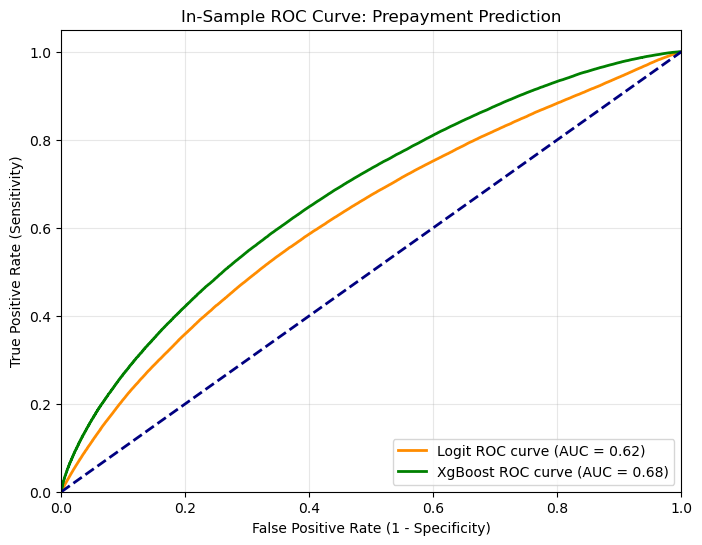

In [11]:

#Calculate the in-sample ROC values
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = roc_auc_score(y, y_prob)

fpr_boost, tpr_boost, thresholds_boost = roc_curve(y, y_prob_boost)
roc_auc_boost = roc_auc_score(y, y_prob_boost)



# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logit ROC curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_boost, tpr_boost, color='green', lw=2, label=f'XgBoost ROC curve (AUC = {roc_auc_boost:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('In-Sample ROC Curve: Prepayment Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [12]:
#Get actual cumulative prepayment rates by DATE_NOW
#Calculate original UPB
start_upb= mort_est_df[['LOAN_ID', 'ORIG_UPB']].drop_duplicates().set_index('LOAN_ID').sum().values[0]

mort_est_df['PREPAID_UPB'] = mort_est_df['PREPAY_FLAG'] * mort_est_df['ORIG_UPB']*mort_est_df['UPB_MULT']
cum_prepay = mort_est_df.groupby('DATE_NOW')['PREPAID_UPB'].sum().cumsum()/start_upb

In [13]:
mort_est_df[['refi_benefit_now', 'refi_benefit_past']].describe()

,refi_benefit_now,refi_benefit_past
count,7.998003e+06,7.998003e+06
mean,-1.721447e+04,-2.290300e+04
std,1.380116e+04,1.513531e+04
min,-2.093957e+05,-2.093957e+05
25%,-2.347059e+04,-3.001494e+04
50%,-1.437128e+04,-1.965276e+04
75%,-7.930181e+03,-1.241594e+04
max,5.771612e+04,5.402846e+04


In [14]:
X_hypo = mort_pred_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 
                       'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
X_hypo1 = sm.add_constant(X_hypo, has_constant='add')
y_prob_hypo = result.predict(X_hypo1)

In [15]:
X_hypo_scaled = scaler.fit_transform(X_hypo)

# Convert to numpy if needed
X_hypo_scaled = X_hypo_scaled.astype('float32')

y_prob_hypo_boost=random_search.predict_proba(X_hypo_scaled)[:, 1]

In [16]:
#Next- use the predicted probabilities to get the expected cumulative prepayment rates over time

# 1. Calculate the 'stay' probability for each specific month
mort_pred_df['PREDICTED_PREPAY_PROB'] = y_prob_hypo
mort_pred_df['STAY_PROB'] = 1 - mort_pred_df['PREDICTED_PREPAY_PROB']

# 2. Ensure the data is ordered by loan and time
mort_pred_df = mort_pred_df.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
mort_pred_df['CUM_STAY_PROB'] = mort_pred_df.groupby('LOAN_ID')['STAY_PROB'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
mort_pred_df['LAG_PROD_SURVIVAL'] = (
    mort_pred_df.groupby('LOAN_ID')['CUM_STAY_PROB']
    .shift(1, fill_value=1.0)
)
mort_pred_df.drop(columns=['STAY_PROB', 'CUM_STAY_PROB'], inplace=True)
mort_pred_df['EXPECTED_PREPAID_UPB'] = mort_pred_df['ORIG_UPB'] * mort_pred_df['UPB_MULT']  * (mort_pred_df['LAG_PROD_SURVIVAL']) * mort_pred_df['PREDICTED_PREPAY_PROB']
agg_expected_prepay = mort_pred_df.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB'].sum().cumsum()/start_upb



In [17]:
#Repeat above cell for xgboost results

# 1. Calculate the 'stay' probability for each specific month
mort_pred_df['PREDICTED_PREPAY_PROB_BOOST'] = y_prob_hypo_boost
mort_pred_df['STAY_PROB_BOOST'] = 1 - mort_pred_df['PREDICTED_PREPAY_PROB_BOOST']

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
mort_pred_df['CUM_STAY_PROB_BOOST'] = mort_pred_df.groupby('LOAN_ID')['STAY_PROB_BOOST'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
mort_pred_df['LAG_PROD_SURVIVAL_BOOST'] = (
    mort_pred_df.groupby('LOAN_ID')['CUM_STAY_PROB_BOOST']
    .shift(1, fill_value=1.0)
)
mort_pred_df.drop(columns=['STAY_PROB_BOOST', 'CUM_STAY_PROB_BOOST'], inplace=True)
mort_pred_df['EXPECTED_PREPAID_UPB_BOOST'] = mort_pred_df['ORIG_UPB'] * mort_pred_df['UPB_MULT']  * (mort_pred_df['LAG_PROD_SURVIVAL_BOOST']) * mort_pred_df['PREDICTED_PREPAY_PROB_BOOST']
agg_expected_prepay_boost = mort_pred_df.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB_BOOST'].sum().cumsum()/start_upb



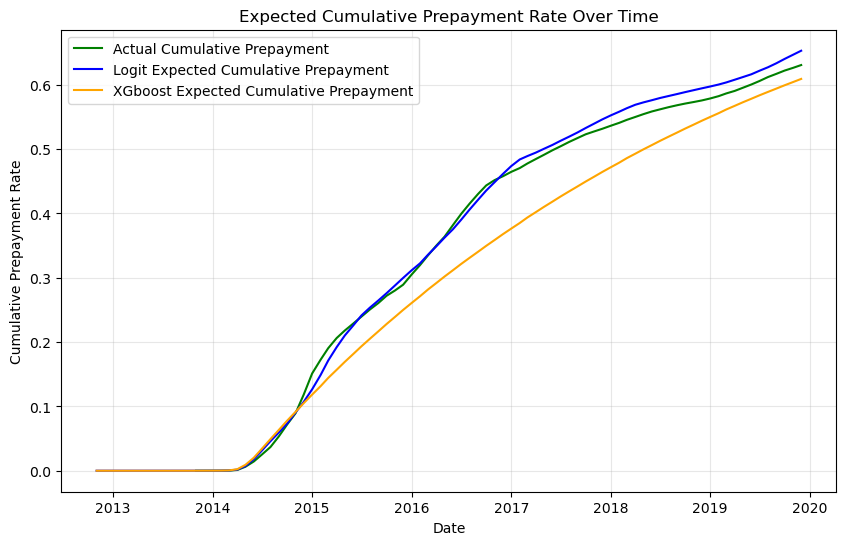

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(cum_prepay.index, cum_prepay.values, label='Actual Cumulative Prepayment', color='Green')
plt.plot(agg_expected_prepay.index, agg_expected_prepay.values, label='Logit Expected Cumulative Prepayment', color='Blue')
plt.plot(agg_expected_prepay_boost.index, agg_expected_prepay_boost.values, label='XGboost Expected Cumulative Prepayment', color='Orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Prepayment Rate')
plt.title('Expected Cumulative Prepayment Rate Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
best_model = random_search.best_estimator_

file_name2 = 'best_boost_model.pkl'
full_path2 = os.path.join(folder_path, file_name2)

# Save only this model (it will be a much smaller file)
joblib.dump(best_model, full_path2)
scaler_path = os.path.join(folder_path, 'scaler.pkl')
joblib.dump(scaler, scaler_path)

['/Users/simonfirestone/Prepayment_Analysis_Data/scaler.pkl']